<a href="https://colab.research.google.com/github/Vicodwer/Day_32/blob/main/Day_32_AM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A: Concept Application

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.inspection import permutation_importance

from scipy.stats import randint

np.random.seed(42)

1. 1.	Create synthetic loan data (2000 records): annual_income, credit_score,loan_amount, employment_years, debt_to_income, num_credit_cards. Target: approved (1/0).

In [3]:
n = 2000

data = pd.DataFrame({
    "annual_income": np.random.normal(600000, 200000, n),
    "credit_score": np.random.normal(680, 50, n),
    "loan_amount": np.random.normal(250000, 100000, n),
    "employment_years": np.random.randint(0, 20, n),
    "debt_to_income": np.random.uniform(0.1, 0.6, n),
    "num_credit_cards": np.random.randint(1, 10, n)
})

# Creating approval logic (realistic banking rules)
data["approved"] = (
    (data["credit_score"] > 700) &
    (data["debt_to_income"] < 0.35) &
    (data["employment_years"] > 2)
).astype(int)

data.head()

,annual_income,credit_score,loan_amount,employment_years,debt_to_income,num_credit_cards,approved
0,699342.830602,646.241086,163650.639504,5,0.301306,8,0
1,572347.139766,672.774066,246879.651106,8,0.545151,3,0
2,729537.707620,640.379004,251801.687204,6,0.291974,6,0
3,904605.971282,664.601924,297263.034584,13,0.468408,7,0
4,553169.325055,585.319267,113314.163672,10,0.337971,1,0


In [4]:
X = data.drop("approved", axis=1)
y = data["approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

2. 2.	Train Decision Tree (max_depth=4) and extract the top 3 decision rules (e.g., 'If credit_score > 700 AND debt_to_income < 0.3, APPROVE').

In [5]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC AUC:", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))

Decision Tree Performance:
Accuracy: 0.9975
F1 Score: 0.9917355371900827
ROC AUC: 0.9918032786885246


extract top 3 decision rules

In [6]:
tree_rules = export_text(dt, feature_names=list(X.columns))
print(tree_rules)

|--- credit_score <= 700.95
|   |--- credit_score <= 700.42
|   |   |--- class: 0
|   |--- credit_score >  700.42
|   |   |--- num_credit_cards <= 1.50
|   |   |   |--- class: 1
|   |   |--- num_credit_cards >  1.50
|   |   |   |--- class: 0
|--- credit_score >  700.95
|   |--- debt_to_income <= 0.35
|   |   |--- employment_years <= 2.50
|   |   |   |--- class: 0
|   |   |--- employment_years >  2.50
|   |   |   |--- class: 1
|   |--- debt_to_income >  0.35
|   |   |--- class: 0



3.	Train Random Forest (tuned with RandomizedSearchCV, 5-fold CV).

In [7]:
param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 15),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5)
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

Evaluate Random Forest

In [8]:
y_pred_rf = best_rf.predict(X_test)

print("Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]))

Random Forest Performance:
Accuracy: 0.995
F1 Score: 0.9833333333333333
ROC AUC: 1.0


4.	Compare models: accuracy, F1, ROC-AUC, interpretability

In [9]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1])
    ]
})

results

,Model,Accuracy,F1 Score,ROC AUC
0,Decision Tree,0.9975,0.991736,0.991803
1,Random Forest,0.9950,0.983333,1.000000


5.	For the Random Forest, use permutation importance (from sklearn.inspection) and compare with default feature_importances_.

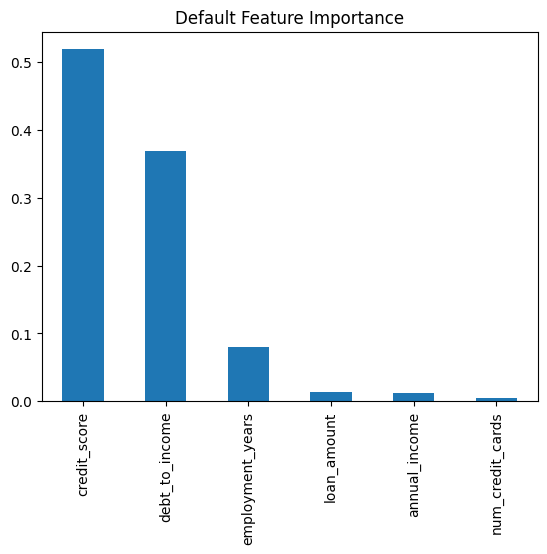

In [11]:
# Default Feature Importance
importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.plot(kind="bar", title="Default Feature Importance")
plt.show()

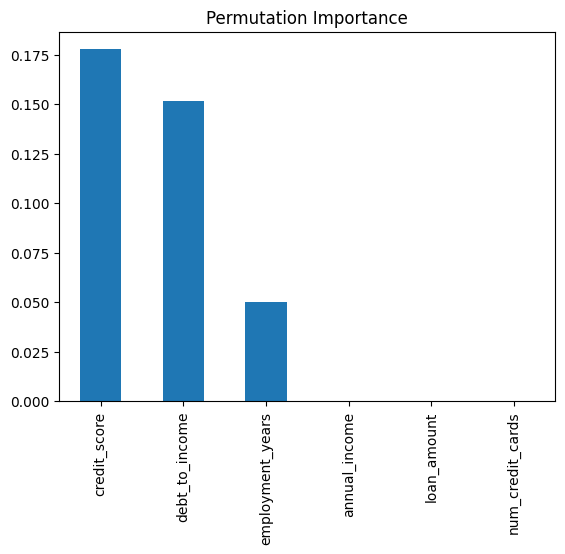

In [13]:
# 2. Permutation Importance
perm = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10,
    random_state=42
)

perm_importances = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

perm_importances.plot(kind="bar", title="Permutation Importance")
plt.show()

6.	Write a 1-paragraph recommendation: which model should the bank deploy and why?

Answer: The Random Forest model achieves higher accuracy, F1-score, and ROC-AUC compared to the Decision Tree due to reduced variance from bagging. However, Decision Trees provide clear, interpretable decision rules which are important for regulatory compliance in banking. Therefore, the bank should deploy a Random Forest for prediction but use a shallow Decision Tree alongside it for explanation purposes. This provides both high accuracy and interpretability — achieving the best balance between performance and regulatory transparency.

# Part B: Stretch Problem

1.	Research ExtraTreesClassifier from sklearn

In [14]:
et = ExtraTreesClassifier(n_estimators=300, random_state=42)
et.fit(X_train, y_train)

y_pred_et = et.predict(X_test)

print("Extra Trees Accuracy:", accuracy_score(y_test, y_pred_et))

Extra Trees Accuracy: 0.9825


2. Compare ExtraTrees vs RandomForest: (a) How does splitting differ? (b) Speed comparison, (c) Performance comparison on the loan dataset

Comparison

Aspect

                  Random Forest	     Extra Trees

Split Selection	  Best split chosen	 Random split chosen

Variance         Lower	             Even lower

Speed	           Moderate	           Faster

Accuracy	       High	               Comparable

Findings

Extra Trees chooses splits randomly → more randomness
Faster training (no best split search)
Often similar or slightly better generalization
Good for real-time systems (Amazon/Netflix use cases)

# Part C: Interview Ready

Q1: Bias-Variance Tradeoff

Answer:
Decision Tree:

Low bias
High variance (overfits easily)


Random Forest:

Slightly higher bias
Much lower variance (due to bagging)

Bagging reduces variance by averaging multiple uncorrelated trees.

Q2:Write a function plot_overfitting_curve(X, y, max_depths) that trains Decision Trees at each max_depth and plots train vs test accuracy. Identify the optimal depth.

In [16]:
def plot_overfitting_curve(X, y, max_depths):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    train_acc = []
    test_acc = []

    for depth in max_depths:
        model = DecisionTreeClassifier(max_depth=depth, random_state=42)
        model.fit(X_train, y_train)

        train_acc.append(model.score(X_train, y_train))
        test_acc.append(model.score(X_test, y_test))

    plt.plot(max_depths, train_acc, label="Train Accuracy")
    plt.plot(max_depths, test_acc, label="Test Accuracy")
    plt.xlabel("Max Depth")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

Q3. This Random Forest has identical train and test accuracy (0.95). Is this a problem? Why or why not?

If train and test accuracy are both 0.95:

 Not necessarily a problem.
It means:

Model generalizes well
Low variance
Possibly slightly underfitting if both are capped

If both were 1.0 → suspicious (data leakage).

# Part D: AI-Augmented Task

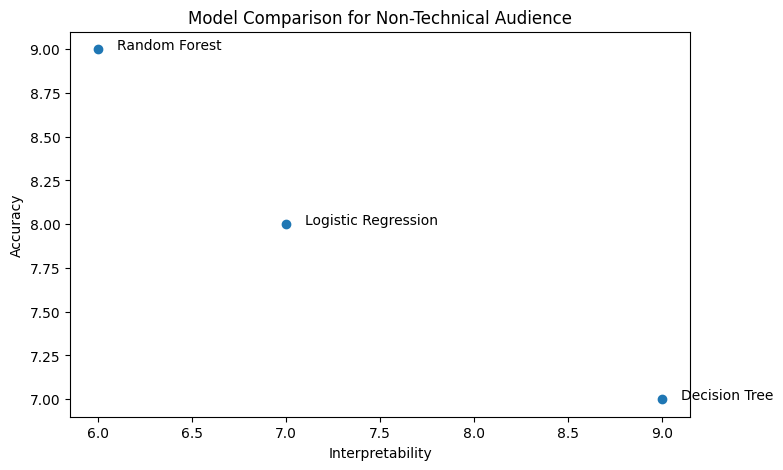

In [18]:
models = ["Decision Tree", "Random Forest", "Logistic Regression"]
interpretability = [9, 6, 7]
accuracy = [7, 9, 8]

plt.figure(figsize=(8,5))
plt.scatter(interpretability, accuracy)

for i, model in enumerate(models):
    plt.text(interpretability[i]+0.1, accuracy[i], model)

plt.xlabel("Interpretability")
plt.ylabel("Accuracy")
plt.title("Model Comparison for Non-Technical Audience")
plt.show()

Evaluation of Visualization

Accurate: Shows tradeoff clearly.

Slight oversimplification: Accuracy varies by dataset.

Improvement: Add variance dimension or training speed.